# DSA 210 Project — Exploratory Data Analysis (EDA)

**Author:** Omer Dogru  
**Project:** Analyzing factors affecting demand for plastic buckets in the dairy industry

## Goal of this notebook
Explore the merged weekly dataset (sales + weather + oil + FX) to understand patterns, seasonality, and relationships before applying statistical tests and ML models.

## Data
- **Sales:** Weekly plastic bucket sales (tons), 2023–2025, from family factory in Osmaniye
- **Weather:** Population-weighted average across 9 major Turkish cities + Osmaniye separately (Open-Meteo API)
- **Oil:** Brent crude futures (Yahoo Finance)
- **FX:** USD/TRY exchange rate (Yahoo Finance)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Load merged data
df = pd.read_csv("data/processed/merged_weekly.csv", parse_dates=["week_start", "week_end"])
df = df.sort_values("week_start").reset_index(drop=True)
print("Shape:", df.shape)
df.head()

Shape: (156, 14)


,year,week,week_start,week_end,sales_tons,temp_tr_mean,temp_tr_max,precip_tr,temp_osmaniye,brent_usd,usd_try,month,quarter,season
0,2023,1,2023-01-02,2023-01-08,40105.0,6.159613,11.126065,1.784211,10.100000,79.056666,18.732950,1,1,Winter
1,2023,2,2023-01-09,2023-01-15,40105.0,7.090548,11.600322,20.724060,8.700000,83.184285,18.770135,1,1,Winter
2,2023,3,2023-01-16,2023-01-22,40105.0,9.663444,15.018797,4.106015,11.071429,86.461428,18.779417,1,1,Winter
3,2023,4,2023-01-23,2023-01-29,40105.0,7.010383,10.868063,17.098246,10.700000,86.841431,18.791903,1,1,Winter
4,2023,5,2023-01-30,2023-02-05,29847.0,3.327462,6.855281,21.012782,7.614286,82.031429,18.804829,1,1,Winter


In [2]:
# General info: types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   year           156 non-null    int64         
 1   week           156 non-null    int64         
 2   week_start     156 non-null    datetime64[ns]
 3   week_end       156 non-null    datetime64[ns]
 4   sales_tons     156 non-null    float64       
 5   temp_tr_mean   156 non-null    float64       
 6   temp_tr_max    156 non-null    float64       
 7   precip_tr      156 non-null    float64       
 8   temp_osmaniye  156 non-null    float64       
 9   brent_usd      156 non-null    float64       
 10  usd_try        156 non-null    float64       
 11  month          156 non-null    int64         
 12  quarter        156 non-null    int64         
 13  season         156 non-null    object        
dtypes: datetime64[ns](2), float64(7), int64(4), object(1)
memory usage: 17.2+ 

In [ ]:
# Descriptive statistics

df.describe().round(2)

In [3]:
# Missing value check
df.isnull().sum()

year             0
week             0
week_start       0
week_end         0
sales_tons       0
temp_tr_mean     0
temp_tr_max      0
precip_tr        0
temp_osmaniye    0
brent_usd        0
usd_try          0
month            0
quarter          0
season           0
dtype: int64

**Observation:** The dataset has 156 weeks (3 full years × 52 weeks) with no missing values across any of the 14 columns. Sales range from ~26,000 to ~105,000 tons per week — a 4× spread that suggests strong variation worth modeling. Temperatures span 1°C to 30°C, covering the full seasonal cycle. USD/TRY climbed from 18.7 to 42.8 over three years, capturing the high-inflation period in Turkey.

## 2. Sales Time Series — The Big Picture

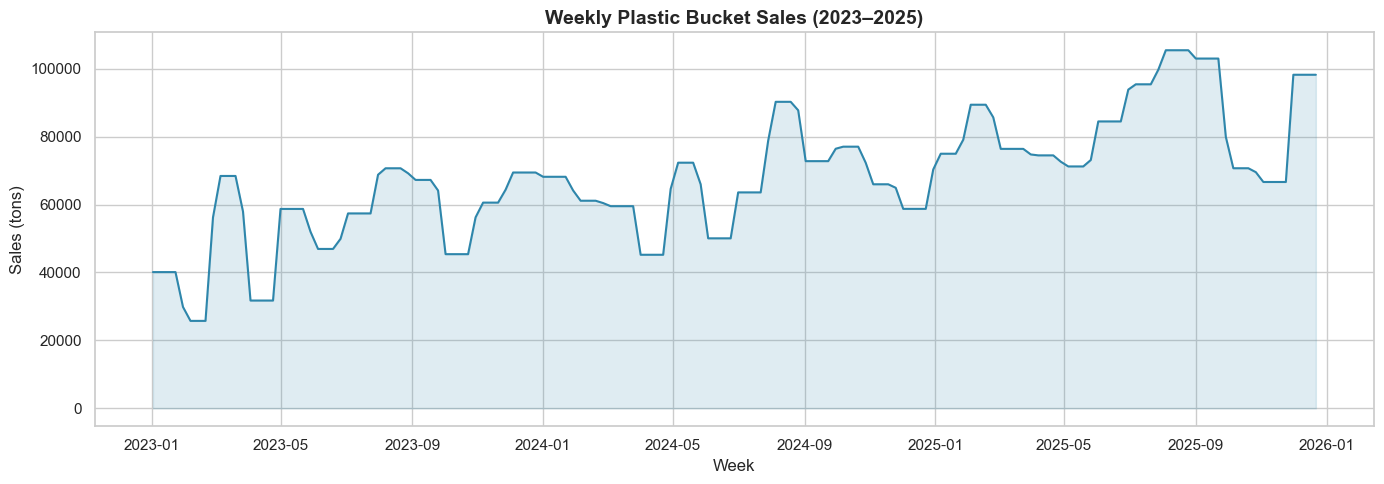

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["week_start"], df["sales_tons"], color="#2E86AB", linewidth=1.5)
ax.fill_between(df["week_start"], df["sales_tons"], alpha=0.15, color="#2E86AB")
ax.set_title("Weekly Plastic Bucket Sales (2023–2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Sales (tons)")
plt.tight_layout()
plt.show()

**Observation:** The series shows a clear upward trend across the three years and a recurring annual pattern — peaks in summer, troughs in winter. This visual evidence supports the project's main hypothesis that warmer periods drive higher bucket demand (more dairy production).

## 3. Year-over-Year Comparison

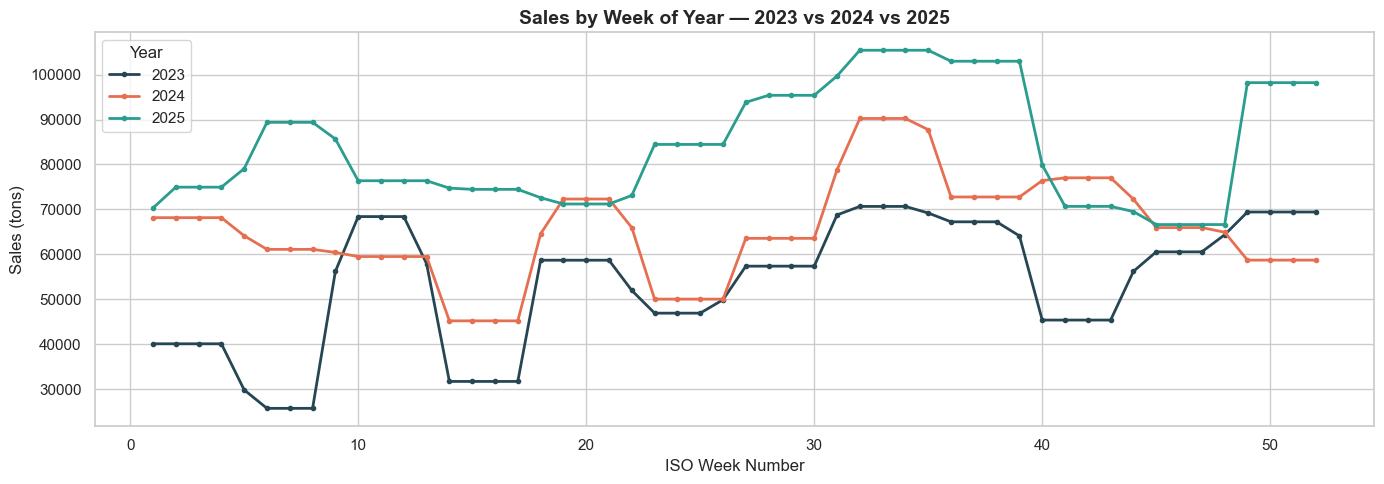

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
for y, color in zip([2023, 2024, 2025], ["#264653", "#E76F51", "#2A9D8F"]):
    sub = df[df["year"] == y]
    ax.plot(sub["week"], sub["sales_tons"], label=str(y), color=color, linewidth=2, marker="o", markersize=3)
ax.set_title("Sales by Week of Year — 2023 vs 2024 vs 2025", fontsize=14, fontweight="bold")
ax.set_xlabel("ISO Week Number")
ax.set_ylabel("Sales (tons)")
ax.legend(title="Year")
plt.tight_layout()
plt.show()

In [6]:
# Yearly totals for context
yearly = df.groupby("year")["sales_tons"].agg(["sum", "mean", "std"]).round(0)
yearly["yoy_growth_%"] = (yearly["sum"].pct_change() * 100).round(1)
yearly

,sum,mean,std,yoy_growth_%
year,,,,
2023,2797979.0,53807.0,14059.0,NaN
2024,3407012.0,65519.0,11272.0,21.8
2025,4362657.0,83897.0,13025.0,28.0


**Observation:** All three years follow the same seasonal shape (low in winter, high in summer), but each year sits noticeably above the previous one. Year-over-year growth is substantial, suggesting either market expansion, capacity growth, or capturing market share — independent of the seasonal effect.

## 4. Seasonality Analysis

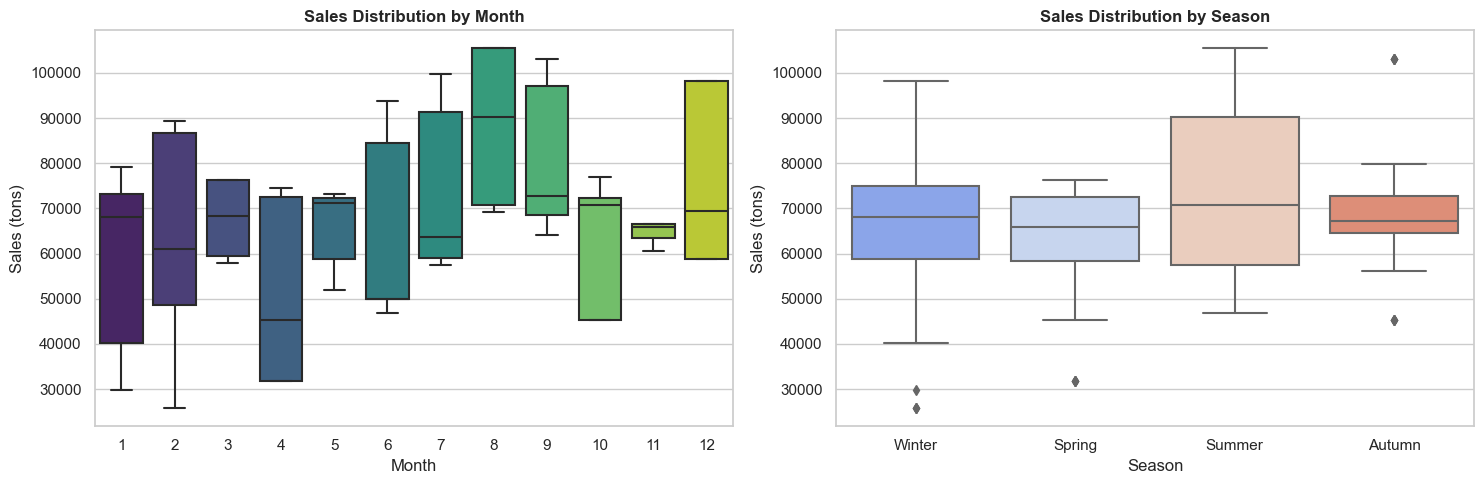

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Monthly distribution
sns.boxplot(data=df, x="month", y="sales_tons", ax=axes[0], palette="viridis")
axes[0].set_title("Sales Distribution by Month", fontweight="bold")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Sales (tons)")

# Seasonal distribution
season_order = ["Winter", "Spring", "Summer", "Autumn"]
sns.boxplot(data=df, x="season", y="sales_tons", order=season_order, ax=axes[1], palette="coolwarm")
axes[1].set_title("Sales Distribution by Season", fontweight="bold")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Sales (tons)")

plt.tight_layout()
plt.show()

In [8]:
# Seasonal averages
df.groupby("season")["sales_tons"].agg(["mean", "median", "std", "count"]).round(0).reindex(season_order)

,mean,median,std,count
season,,,,
Winter,65066.0,68161.0,20453.0,39
Spring,61695.0,65947.0,13939.0,39
Summer,74382.0,70666.0,19537.0,39
Autumn,69822.0,67238.0,14291.0,39


**Observation:** Sales rise gradually from winter through spring, peak in summer, and decline through autumn. Summer median sales appear visibly higher than winter — this gap is exactly what we'll formally test with hypothesis tests in the next notebook.

## 5. The Main Hypothesis: Temperature ↔ Sales

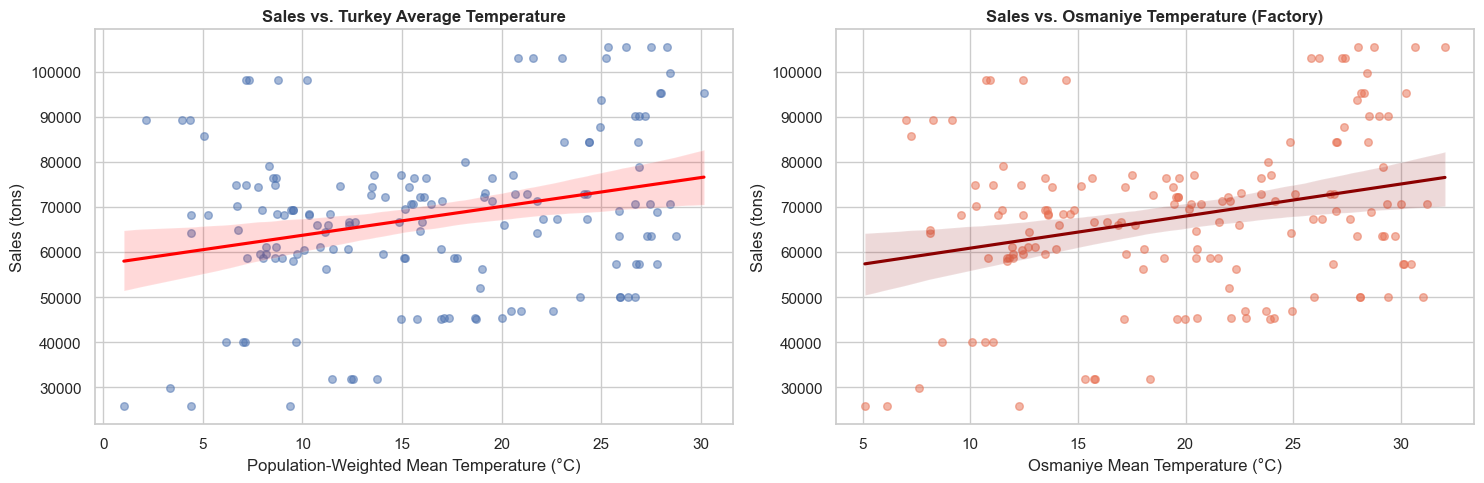

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Turkey-wide weighted temperature
sns.regplot(data=df, x="temp_tr_mean", y="sales_tons", ax=axes[0],
            scatter_kws={"alpha": 0.5, "s": 30}, line_kws={"color": "red"})
axes[0].set_title("Sales vs. Turkey Average Temperature", fontweight="bold")
axes[0].set_xlabel("Population-Weighted Mean Temperature (°C)")
axes[0].set_ylabel("Sales (tons)")

# Osmaniye (factory location)
sns.regplot(data=df, x="temp_osmaniye", y="sales_tons", ax=axes[1],
            scatter_kws={"alpha": 0.5, "s": 30, "color": "#E76F51"}, line_kws={"color": "darkred"})
axes[1].set_title("Sales vs. Osmaniye Temperature (Factory)", fontweight="bold")
axes[1].set_xlabel("Osmaniye Mean Temperature (°C)")
axes[1].set_ylabel("Sales (tons)")

plt.tight_layout()
plt.show()

**Observation:** Both scatter plots show a positive linear relationship between temperature and sales. The Turkey-wide weighted temperature appears to give a slightly tighter fit, which makes sense because sales serve customers nationwide, not just near the factory. We will quantify this with correlation and hypothesis tests in the next notebook.

## 6. Correlation Heatmap — All Numeric Variables

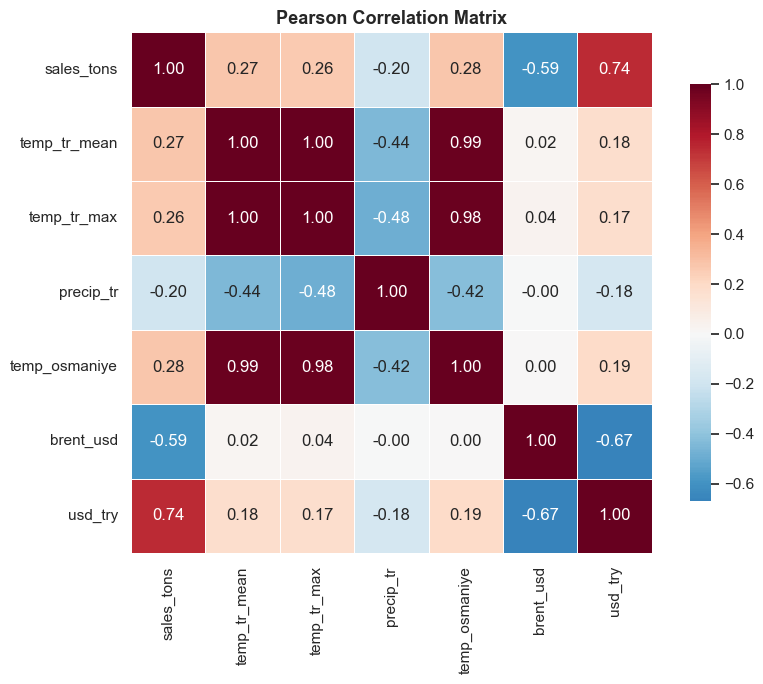

In [10]:
numeric_cols = ["sales_tons", "temp_tr_mean", "temp_tr_max", "precip_tr",
                "temp_osmaniye", "brent_usd", "usd_try"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** Sales correlates positively with temperature variables (both Turkey-wide and Osmaniye), and also with USD/TRY — the latter likely reflects the upward trend in both series rather than a causal link. Brent shows a weaker relationship. Temperature variables are highly correlated with each other (expected), so we'll be careful not to use both in the same regression model later.

## 7. Sales Distribution

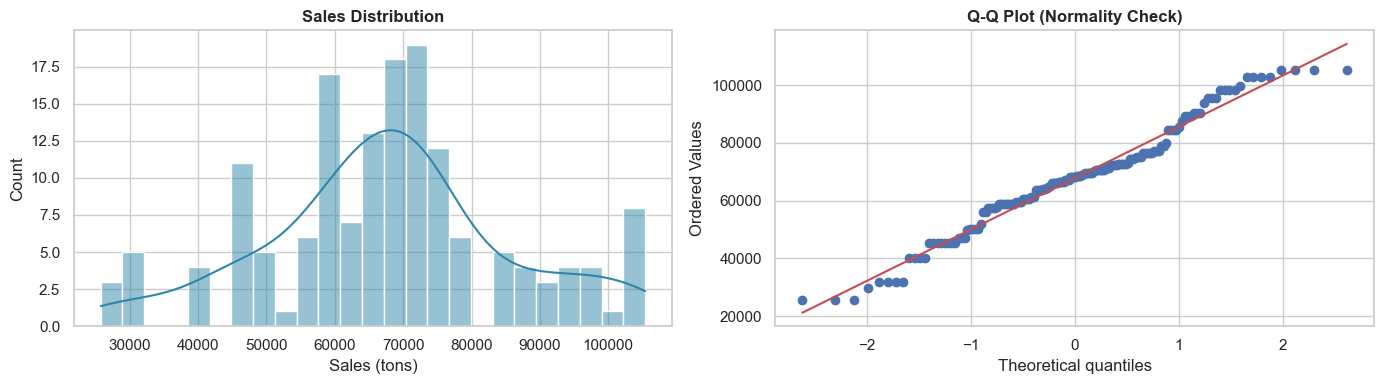

Shapiro-Wilk test: W = 0.9738, p = 0.0046
-> Sales are NOT normally distributed.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["sales_tons"], bins=25, kde=True, ax=axes[0], color="#2E86AB")
axes[0].set_title("Sales Distribution", fontweight="bold")
axes[0].set_xlabel("Sales (tons)")

from scipy import stats
stats.probplot(df["sales_tons"], dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot (Normality Check)", fontweight="bold")

plt.tight_layout()
plt.show()

# Formal normality test
stat, p = stats.shapiro(df["sales_tons"])
print(f"Shapiro-Wilk test: W = {stat:.4f}, p = {p:.4f}")
print("-> Sales are NOT normally distributed." if p < 0.05 else "-> Sales appear normally distributed.")

**Observation:** The distribution is roughly bell-shaped but the Q-Q plot deviates from the diagonal at the tails, and the Shapiro-Wilk test rejects normality. This means we should prefer **non-parametric tests** (Mann-Whitney U, Spearman, Kruskal-Wallis) over their parametric counterparts in the hypothesis testing notebook.

## 8. External Drivers — Brent and USD/TRY Over Time

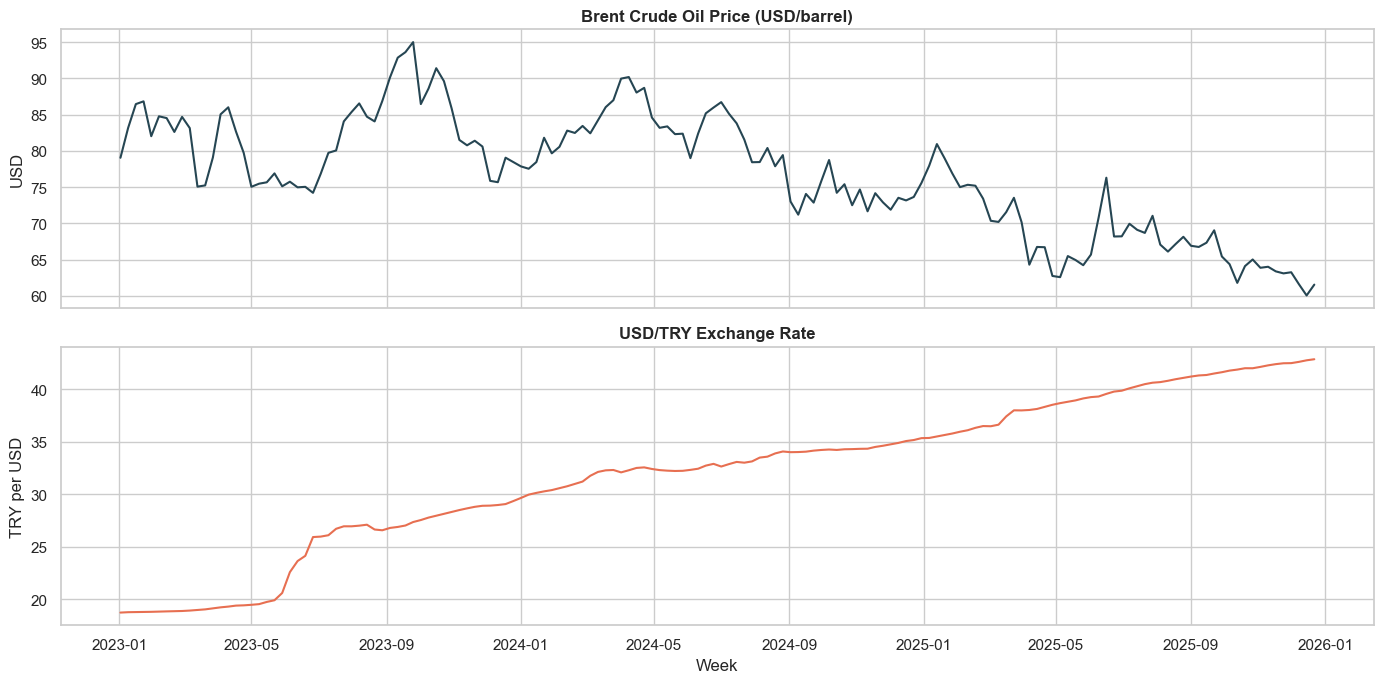

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(df["week_start"], df["brent_usd"], color="#264653", linewidth=1.5)
axes[0].set_title("Brent Crude Oil Price (USD/barrel)", fontweight="bold")
axes[0].set_ylabel("USD")

axes[1].plot(df["week_start"], df["usd_try"], color="#E76F51", linewidth=1.5)
axes[1].set_title("USD/TRY Exchange Rate", fontweight="bold")
axes[1].set_ylabel("TRY per USD")
axes[1].set_xlabel("Week")

plt.tight_layout()
plt.show()

**Observation:** Brent oscillates within a band of roughly USD 60–95 with no clear trend. USD/TRY rises sharply and persistently — more than doubling over the period — reflecting Turkey's currency depreciation. Because USD/TRY moves in one direction over the whole sample, any correlation with sales (which also trends upward) is likely *spurious* rather than causal. We should keep this caveat in mind.

## 9. Sales vs. Temperature with Seasonal Coloring

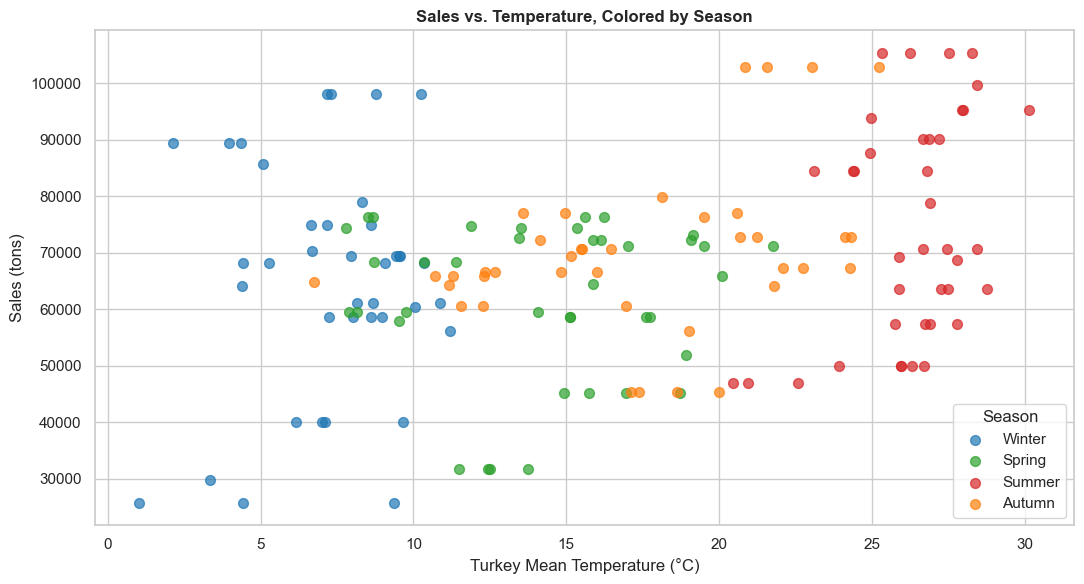

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
season_colors = {"Winter": "#1f77b4", "Spring": "#2ca02c", "Summer": "#d62728", "Autumn": "#ff7f0e"}
for s in season_order:
    sub = df[df["season"] == s]
    ax.scatter(sub["temp_tr_mean"], sub["sales_tons"], label=s, color=season_colors[s], alpha=0.7, s=50)
ax.set_title("Sales vs. Temperature, Colored by Season", fontweight="bold")
ax.set_xlabel("Turkey Mean Temperature (°C)")
ax.set_ylabel("Sales (tons)")
ax.legend(title="Season")
plt.tight_layout()
plt.show()

**Observation:** The seasons cleanly stratify along the temperature axis (winter cold → summer hot), and sales generally rise with temperature. Some overlap exists between spring and autumn at similar temperatures — interesting because it suggests the relationship is mostly temperature-driven rather than purely calendar-driven.

## 10. Summary of EDA Findings

1. **No data quality issues.** 156 weeks, 0 missing values across all 14 columns.
2. **Strong upward trend.** Sales grew substantially year over year (2023 → 2024 → 2025), independent of seasonal effects.
3. **Clear seasonality.** Summer sales are visibly higher than winter sales; this pattern repeats every year.
4. **Temperature ↔ sales link is visible.** Scatter plots show a positive linear relationship; correlation matrix confirms moderate-to-strong positive correlation.
5. **USD/TRY correlation is likely spurious.** Both series trend upward, so correlation does not imply causation here.
6. **Brent oil shows weak relationship** with sales in raw form.
7. **Sales are not normally distributed** (Shapiro-Wilk rejects normality), so we will use non-parametric tests in the hypothesis testing notebook.

## Next steps
- Notebook `02_hypothesis_tests.ipynb`: Formal statistical tests for the relationships observed here.
- Later: Feature engineering (lags, season indicators) and machine learning models for sales prediction.